# Student Performance Prediction
 Predict whether a student will score Pass or Fail based on:
- Study Hours
- Attendance
- Assignments Completed
- Previous Mark

In [30]:
# import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Load Dataset
dataset = pd.read_csv("C:/Users/Uma Maheswara Rao/Desktop/Predictive_Modeling_Project/dataset/student_data.csv")
print(dataset.head())

   Student_ID  Study_Hours  Attendance  Assignments  Previous_Marks Result
0           1            5          80            8              65   Pass
1           2            2          50            3              40   Fail
2           3            6          85            9              70   Pass
3           4            1          40            2              35   Fail
4           5            7          90           10              80   Pass


# Convert Target Variable
Machine learning cannot understand text.

Convert:
Pass → 1
Fail → 0

In [31]:
label_encoder = LabelEncoder()

dataset['Result'] = label_encoder.fit_transform(
    dataset['Result']
)
dataset.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Result
0,1,5,80,8,65,1
1,2,2,50,3,40,0
2,3,6,85,9,70,1
3,4,1,40,2,35,0
4,5,7,90,10,80,1


In [32]:
# Define Features and Target
feature_columns = [
    'Study_Hours',
    'Attendance',
    'Assignments',
    'Previous_Marks'
]
X = dataset[feature_columns]
y = dataset['Result']

#Split Data :  Training = 80% , Testing = 20%
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Train Decision Tree

In [33]:
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_train,y_train)

#Predict
decision_tree_predictions = decision_tree_model.predict(X_test)

# Accuracy
decision_tree_accuracy = accuracy_score(y_test,decision_tree_predictions)
print("Decision Tree Accuracy:",decision_tree_accuracy)

Decision Tree Accuracy: 1.0


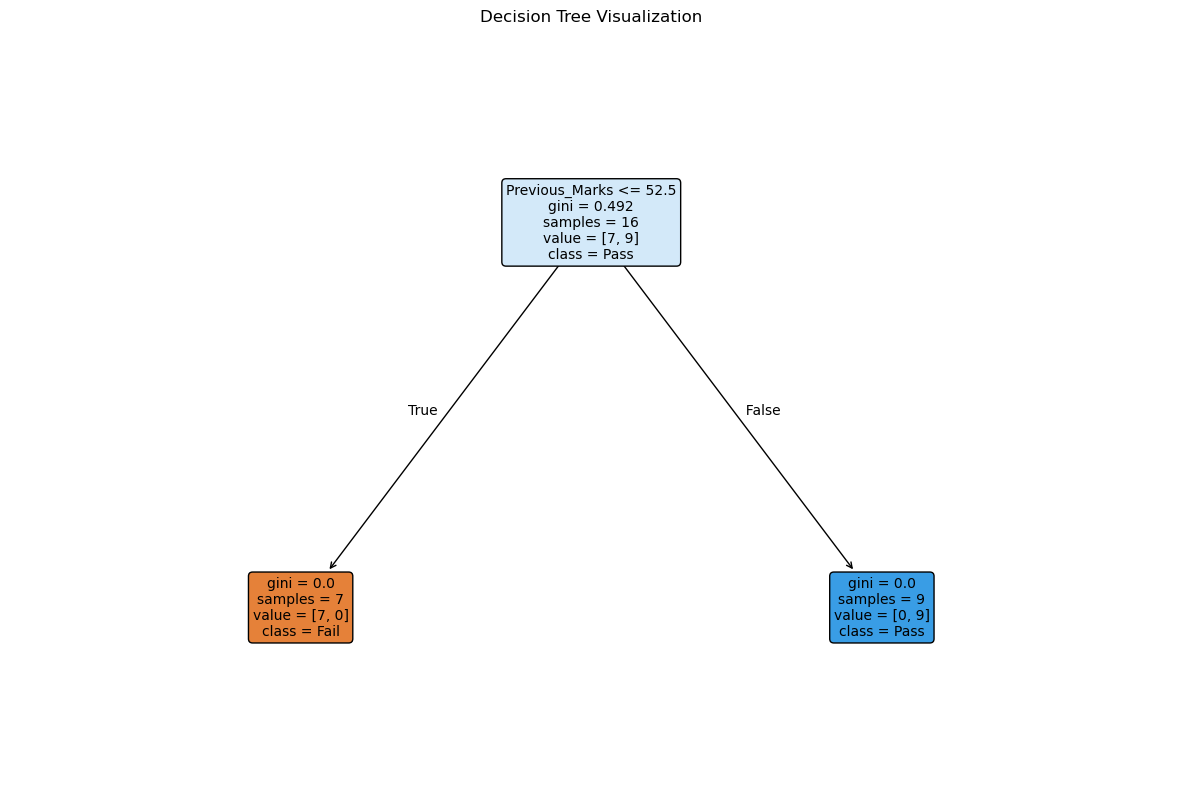

In [34]:
# Decision Tree Visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

plot_tree(
    decision_tree_model,
    feature_names=feature_columns,
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

# Train Random Forest

In [35]:
random_forest_model = RandomForestClassifier(n_estimators=100,random_state=42)
random_forest_model.fit(X_train,y_train)

# Random Forest Prediction
random_forest_predictions = random_forest_model.predict(X_test)
random_forest_accuracy = accuracy_score(y_test,random_forest_predictions)
print("Random Forest Accuracy:",random_forest_accuracy)

Random Forest Accuracy: 1.0


# Visualize One Tree from Random Forest

A Random Forest is a collection of many Decision Trees

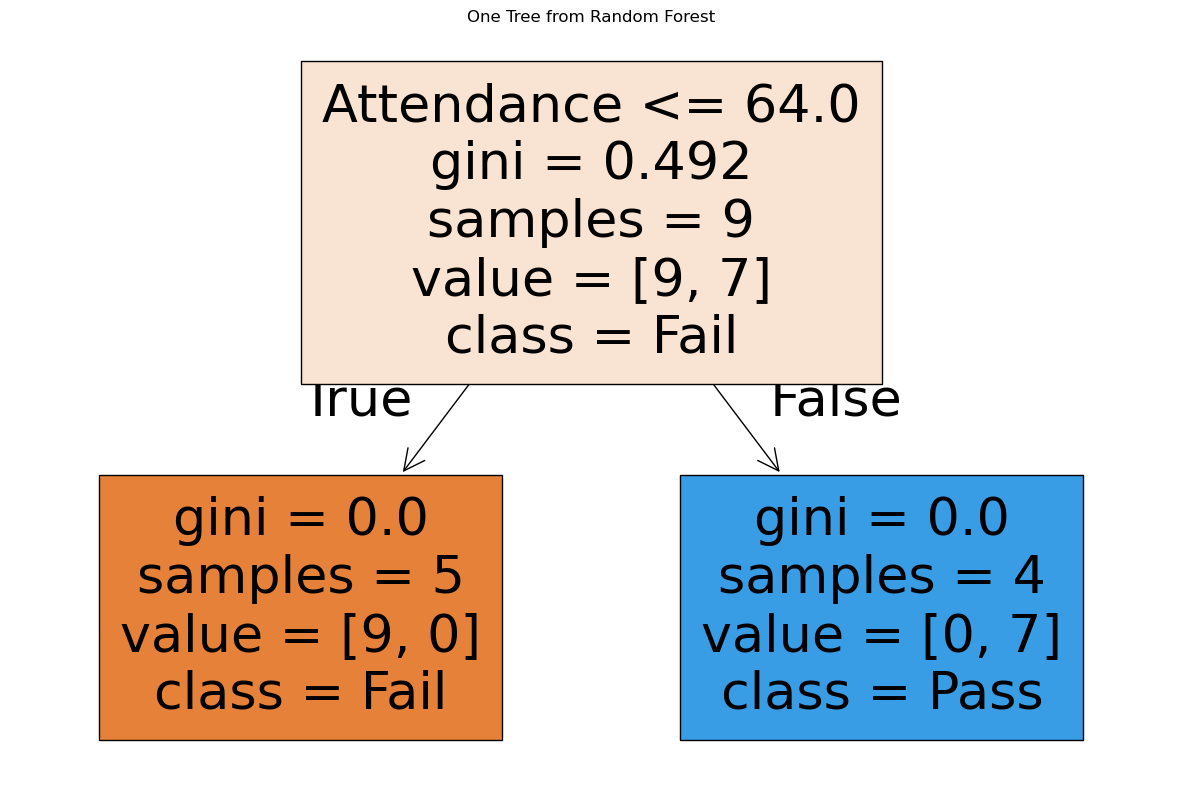

In [36]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

single_tree = random_forest_model.estimators_[0]

plt.figure(figsize=(15,10))

plot_tree(
    single_tree,
    feature_names=feature_columns,
    class_names=['Fail', 'Pass'],
    filled=True
)

plt.title("One Tree from Random Forest")

plt.show()

# Confusion Matrix

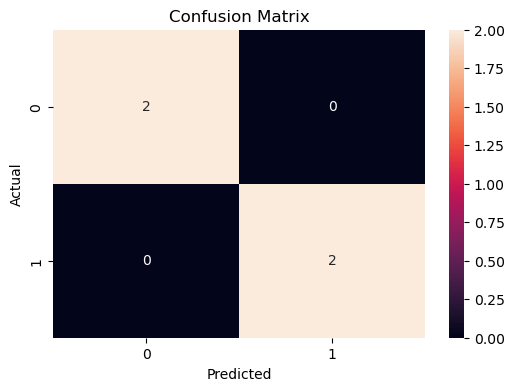

In [37]:
confusion_matrix_result = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix_result,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Feature Importance

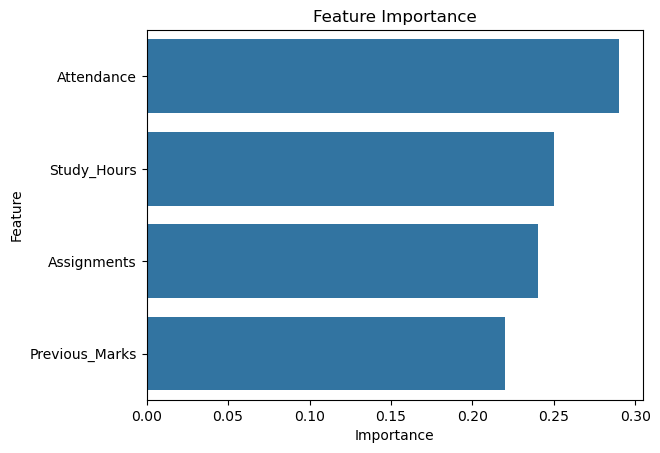

In [38]:
importance_values = random_forest_model.feature_importances_

importance_dataset = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importance_values
})

importance_dataset.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_dataset
)

plt.title(
    "Feature Importance"
)

plt.show()

# Classification Report

In [39]:
print(
    classification_report(
        y_test,
        random_forest_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Compare Model Accuracy

This graph looks very good in internship reports.

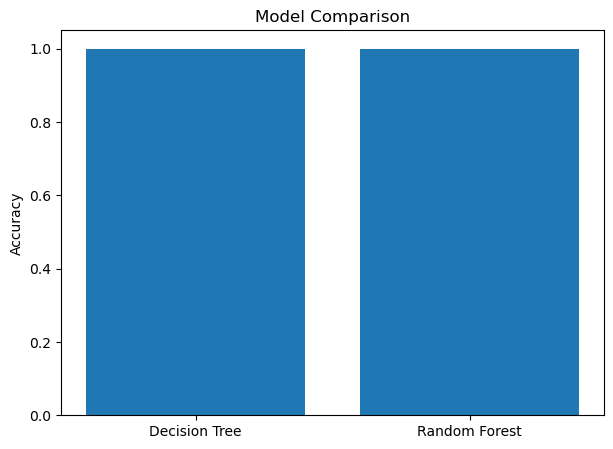

In [40]:
models = ['Decision Tree', 'Random Forest']

accuracies = [
    decision_tree_accuracy,
    random_forest_accuracy
]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()